In [1]:
%reload_ext autoreload
%autoreload 2
%cd ~/erc-src/cuneiform-ocr-sign-alignment-worktree # Change to the project directory
%env PATH=$HOME/.local/bin:$PATH
    
import json
import os
import requests
import numpy as np
import cv2
from PIL import Image
from pymongo import MongoClient
# from mmdet.apis import init_detector, inference_detector
# from mmdet.utils import register_all_modules
from data_processing.divide_photos import divide_tablet_photo
from sign_alignment.detector import ModelConfig, TabletImageDetector

# import signs_alignment as sa
import os
import torch
from dotenv import load_dotenv

ANNOTATIONS_DIR = os.path.expanduser("~/erc-work-data/data-of-cuneiform-ocr-data/filtered_annotations")
CONFIG_FILE = "configs/detr.py"
CHECKPOINT_FILE = os.path.expanduser("~/erc-work-data/retrained_models/detr-173/epoch_1000.pth")
# # temporal change
# CHECKPOINT_FILE = os.path.expanduser("~/epoch_1000.pth")
# ANNOTATIONS_DIR = os.path.expanduser("~/filtered_annotations")
# # ---
SCORE_THRESHOLD = 0.5
Y_THRESHOLD = 35  # for grouping signs into lines
OUTPUT_DIR = "alignment_results"
SAMPLE_LIMIT = 5  # number of samples to process

load_dotenv()
MONGODB_URI = os.getenv('MONGODB_URI', 'YOUR_MONGODB_URI')

# colors for visualization
GT_COLOR = (0, 255, 0)  # Green for GT
DET_COLOR = (255, 0, 0)  # Red for Detected
OPTIM_COLOR = (0, 255, 255)  # cyan for Optimized

[Errno 2] No such file or directory: '/home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree # Change to the project directory'
/home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree
env: PATH=$HOME/.local/bin:$PATH
classes setting in current coco.py: ['LU₂', 'MU', 'NU', 'DIŠ', 'AN', 'UD', 'KUL', 'A', 'ŠU₂', 'GAR', 'AK', 'KI', 'UnclearSign', 'EN', 'ŠEŠ', 'MEŠ', 'BA', 'ŠID', 'U', 'AMAR', 'IGI', 'U₂', 'DIN', '|UD×(U.U.U)|', '|U.5(DIŠ)|', '|HI×BAD|', 'DU', 'HA', 'TA', 'PAP', 'I', 'GABA', 'SA', 'DI', 'AŠ', 'RI', 'TI', 'RU', 'MA', '|U.KA|', 'NI', 'ŠU', 'ŠA₃', 'KA', 'GIŠ', 'KU', 'AD', 'TE', 'TAR', 'UŠ', 'KAK', 'BAD', 'ZE₂', 'SAG', 'SI', 'BI', 'MI', 'NE', 'LUGAL', 'NA', 'HI', 'IM', 'BU', '|U.GUD|', 'A₂', 'ZU', '|U.U|', 'RA', 'MIN', 'DUN₃@g', 'PI', 'SAL', 'KAL', 'GI', 'KUR', 'ME', 'SU', 'E₂', 'KID', 'TUR', 'LA', 'ZA', 'DA', 'NAM', 'ZI', 'LU', 'E', 'ŠA', 'ŠE', 'GAL', 'LI', 'IB', 'DIM₂', 'GA', 'TUM', 'PA', 'HU', '|U.U.U|', 'MAŠ', 'GAN', 'TU', '|HI×AŠ₂|', 'KU₃', 'AB', 'IG', '|I.A|']

In [2]:
model_config = ModelConfig(
    config_file=CONFIG_FILE,
    checkpoint_file=CHECKPOINT_FILE,
    device='auto'
)
tablet_detector = TabletImageDetector(
    model_config=model_config,
    score_threshold=SCORE_THRESHOLD,
    keep_crops=True
)

Initializing detector, loading model...
Using device: cuda:0
Loads checkpoint by local backend from path: /home/jebediahc/erc-work-data/retrained_models/detr-173/epoch_1000.pth


In [3]:
from sign_alignment.data_source import LocalDataSource

local_source = LocalDataSource(ANNOTATIONS_DIR)
fragments = local_source.get_available_fragments()
print(f"Found {len(fragments)} fragments with both image and annotation")
sample = fragments[0] # NBC.4020
sample = fragments[9] # HS.2086 , HS.450 if use local temporal change
print(f"Processing sample: {sample}")


Found 947 fragments with both image and annotation
Processing sample: HS.2086


In [4]:
# show groud truth boxes
from sign_alignment.visualizer import BboxVisualizer

img = local_source.load_image(sample)
gt_boxes = local_source.load_annotation(sample)
print(f"Ground truth boxes: {len(gt_boxes)}")

gt_bbox_visualizer = BboxVisualizer(color=(0, 255, 0)) # green for gt
gt_bbox_visualizer.draw_boxes(img.copy(), gt_boxes)
gt_bbox_visualizer.save(os.path.join(OUTPUT_DIR, f"debug_{sample}_gt.jpg"))

Ground truth boxes: 397
✓ Saved to: /home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree/alignment_results/debug_HS.2086_gt.jpg


In [7]:
# get sign text (gt) from text.lines with broken sign filtering
from sign_alignment.data_source import EBLAPISource, SignTextParser, SignAPIResolver
from sign_alignment.visualizer import TextVisualizer

api_source = EBLAPISource()
sign_resolver = SignAPIResolver()

# Get fragment data and extract text from text.lines (instead of signs field)
fragment_data = api_source.get_fragment_data(sample)
if fragment_data is None:
    raise ValueError(f"No fragment data found for sample {sample}")

text_data = fragment_data.get('text', {})
text_lines = SignTextParser.parse_text_lines(text_data, filter_broken=True, sign_resolver=sign_resolver)

total_text_signs = sum(len(line) for line in text_lines)
print(f"  Text lines: {len(text_lines)}, total signs: {total_text_signs}")

# Also show unfiltered for comparison
text_lines_unfiltered = SignTextParser.parse_text_lines(text_data, filter_broken=False, sign_resolver=sign_resolver)
total_unfiltered = sum(len(line) for line in text_lines_unfiltered)
print(f"  Unfiltered: {total_unfiltered} signs, broken signs removed: {total_unfiltered - total_text_signs}")

# print all text lines
TextVisualizer.save_text(text_lines, path=os.path.join(OUTPUT_DIR, f"debug_{sample}_text_filtered.txt"), fragment_id=sample)
TextVisualizer.save_text(text_lines_unfiltered, path=os.path.join(OUTPUT_DIR, f"debug_{sample}_text.txt"), fragment_id=sample)

  Text lines: 47, total signs: 498
  Unfiltered: 506 signs, broken signs removed: 8


In [8]:
# detect signs
from sign_alignment.visualizer import BboxVisualizer

# Use tablet_detector created in cell 2
detections = tablet_detector.detect(img)

det_bbox_visualizer = BboxVisualizer(color=DET_COLOR)
det_bbox_visualizer.draw_boxes(img.copy(), detections)
det_bbox_visualizer.save(os.path.join(OUTPUT_DIR, f"debug_{sample}_det.jpg"))

cropped = tablet_detector.get_cropped_images()
exp_image_idx = 1
exp_image = cropped[exp_image_idx]

det_bbox_visualizer.draw_boxes(exp_image.img.copy(), exp_image.detections)
det_bbox_visualizer.save(os.path.join(OUTPUT_DIR, f"debug_{sample}_exp_image.jpg"))

/home/jebediahc/anaconda3/envs/cuneiform-ocr/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


✓ Saved to: /home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree/alignment_results/debug_HS.2086_det.jpg
✓ Saved to: /home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree/alignment_results/debug_HS.2086_exp_image.jpg


In [9]:
# Transform GT boxes for exp_image (cropped region)
from sign_alignment import transform_gt_to_cropped_region

# exp_image is cropped[3], so we need crop_coordinates[3]
crop_info = tablet_detector.crop_coordinates[exp_image_idx]

print(f"Crop info for exp_image (index {exp_image_idx}): x={crop_info['x']}, y={crop_info['y']}, w={crop_info['w']}, h={crop_info['h']}")

# Transform GT boxes to exp_image coordinates
gt_boxes_exp = transform_gt_to_cropped_region(gt_boxes, crop_info)
print(f"GT boxes in full image: {len(gt_boxes)}")
print(f"GT boxes in exp_image: {len(gt_boxes_exp)}")

# Visualize GT boxes on exp_image
if gt_boxes_exp:
    gt_exp_bbox_visualizer = BboxVisualizer(color=GT_COLOR)  
    gt_exp_bbox_visualizer.draw_boxes(exp_image.img.copy(), gt_boxes_exp)
    gt_exp_bbox_visualizer.display_result(vis_opt="save", path=os.path.join(OUTPUT_DIR, f"debug_{sample}_exp_gt.jpg"))

Crop info for exp_image (index 1): x=908, y=95, w=1262, h=2835
GT boxes in full image: 397
GT boxes in exp_image: 187
✓ Saved to: /home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree/alignment_results/debug_HS.2086_exp_gt.jpg


In [10]:
# statistics
from sign_alignment import compute_avg_dimensions

avg_width, avg_height = compute_avg_dimensions(detections)
print(f"full image shape: {img.shape}")
print(f"Exp image shape: {exp_image.img.shape}")
print(f"Average detected sign width: {avg_width:.2f}, height: {avg_height:.2f}")

full image shape: (8830, 3071, 3)
Exp image shape: (2835, 1262, 3)
Average detected sign width: 138.99, height: 133.66


In [11]:
# create sub-tablets, text and detection, for further alignment
from sign_alignment import SubTablet

# --- 1. Detection SubTablet (target X) ---
sub_tablet_detection = SubTablet.from_detections(
    img=exp_image.img,
    detections=exp_image.detections,
    name="detection",
    avg_width=avg_width,
    avg_height=avg_height,
)

# --- 2. Text SubTablet (source S), centroid-initialised ---
# the signs are distributed in lines using avg_width and avg_height, and aligned to the centroid of the detection boxes. But it doesn't matter if we don't use the boxes positions information.
sub_tablet_text = SubTablet.from_text_lines(
    text_lines=text_lines,
    avg_width=avg_width,
    avg_height=avg_height,
    img=exp_image.img,
    target_detections=exp_image.detections,
    align_to_detection_centroid=True,
    name="text",
) 

print(f"Sub-tablet detection: {sub_tablet_detection.info}")
print(f"Sub-tablet text: {sub_tablet_text.info}")

Sub-tablet detection: SubTablet 'detection':
  100 signs, 1 rows, 
  image shape: (2835, 1262, 3), heatmap shape: None
  avg_width: 138.99, avg_height: 133.66
Sub-tablet text: SubTablet 'text':
  498 signs, 47 rows, 
  image shape: (2835, 1262, 3), heatmap shape: None
  avg_width: 138.99, avg_height: 133.66


In [12]:
# 从这里开始添加我们的optimize前处理

# ===== Step 1: Row Detection using DBSCAN =====

# Detect rows in sub_tablet_detection and update row_idx for all sign_boxes
# Using custom distance metric: Dist(A,B) = sqrt(lambda*(x_A-x_B)^2 + (y_A-y_B)^2)
# where lambda=0.05 emphasizes y-coordinate proximity
# 
# Distance is normalized by average sign size for scale invariance:
# eps=0.6 means boxes within 0.6 * avg_size are considered neighbors
num_rows = sub_tablet_detection.detect_rows(
    eps=0.4,           # Distance threshold as multiple of avg sign size
    min_samples=1,     # Minimum samples per cluster
    lambda_weight=0.007 # Weight for x-coordinate (emphasizes y)
)

print(f"=== Row Detection Results (Scale-Normalized) ===")
print(f"Average sign size: {(sub_tablet_detection.avg_width + sub_tablet_detection.avg_height) / 2:.2f} pixels")
print(f"eps=0.6 → actual distance threshold ≈ {0.6 * (sub_tablet_detection.avg_width + sub_tablet_detection.avg_height) / 2:.2f} pixels")
print(f"Detected {num_rows} rows")
print(f"Number of signs: {len(sub_tablet_detection)}")

# Count boxes per row
from collections import Counter
row_labels = [sb.row_idx for sb in sub_tablet_detection.sign_boxes]
row_counts = Counter(row_labels)
print(f"\nBoxes per row:")
for row_idx in sorted(row_counts.keys()):
    if row_idx == -1:
        print(f"  Noise: {row_counts[row_idx]} boxes")
    else:
        print(f"  Row {row_idx}: {row_counts[row_idx]} boxes")

# Show first few signs with row info
print(f"\nFirst 5 signs with row info:")
for i, sb in enumerate(sub_tablet_detection.sign_boxes[:5]):
    print(f"  {i+1}. {sb.sign_name} (row={sb.row_idx}): center=({sb.cx:.1f}, {sb.cy:.1f})")

=== Row Detection Results (Scale-Normalized) ===
Average sign size: 136.33 pixels
eps=0.6 → actual distance threshold ≈ 81.80 pixels
Detected 28 rows
Number of signs: 100

Boxes per row:
  Row 0: 2 boxes
  Row 1: 4 boxes
  Row 2: 8 boxes
  Row 3: 6 boxes
  Row 4: 6 boxes
  Row 5: 1 boxes
  Row 6: 5 boxes
  Row 7: 5 boxes
  Row 8: 5 boxes
  Row 9: 2 boxes
  Row 10: 1 boxes
  Row 11: 1 boxes
  Row 12: 5 boxes
  Row 13: 2 boxes
  Row 14: 5 boxes
  Row 15: 4 boxes
  Row 16: 1 boxes
  Row 17: 5 boxes
  Row 18: 5 boxes
  Row 19: 3 boxes
  Row 20: 2 boxes
  Row 21: 1 boxes
  Row 22: 5 boxes
  Row 23: 4 boxes
  Row 24: 6 boxes
  Row 25: 1 boxes
  Row 26: 3 boxes
  Row 27: 2 boxes

First 5 signs with row info:
  1. IN (row=18): center=(522.9, 1834.2)
  2. |U.U.U| (row=14): center=(991.0, 1462.2)
  3. ZE₂ (row=2): center=(223.8, 459.1)
  4. DIŠ (row=16): center=(103.6, 1672.6)
  5. BA (row=3): center=(762.1, 526.3)


In [13]:
# ===== Step 4: Detect rows in text subtablet =====

# Detect rows in text subtablet (already has row_idx from from_text_lines)
# But we need to make sure they're properly sorted
num_rows_text = len(sub_tablet_text.get_rows())

print(f"=== Text SubTablet Row Info ===")
print(f"Number of rows: {num_rows_text}")
print(f"Number of signs: {len(sub_tablet_text)}")

# Count signs per row
row_counts_text = Counter([sb.row_idx for sb in sub_tablet_text.sign_boxes])
print(f"\nSigns per text row:")
for row_idx in sorted(row_counts_text.keys()):
    if row_idx >= 0:
        print(f"  Row {row_idx}: {row_counts_text[row_idx]} signs")

=== Text SubTablet Row Info ===
Number of rows: 47
Number of signs: 498

Signs per text row:
  Row 0: 5 signs
  Row 1: 5 signs
  Row 2: 13 signs
  Row 3: 11 signs
  Row 4: 14 signs
  Row 5: 8 signs
  Row 6: 9 signs
  Row 7: 8 signs
  Row 8: 15 signs
  Row 9: 11 signs
  Row 10: 13 signs
  Row 11: 9 signs
  Row 12: 10 signs
  Row 13: 7 signs
  Row 14: 25 signs
  Row 15: 7 signs
  Row 16: 9 signs
  Row 17: 11 signs
  Row 18: 12 signs
  Row 19: 10 signs
  Row 20: 9 signs
  Row 21: 9 signs
  Row 22: 8 signs
  Row 23: 6 signs
  Row 24: 9 signs
  Row 25: 8 signs
  Row 26: 12 signs
  Row 27: 17 signs
  Row 28: 12 signs
  Row 29: 17 signs
  Row 30: 12 signs
  Row 31: 16 signs
  Row 32: 16 signs
  Row 33: 9 signs
  Row 34: 13 signs
  Row 35: 14 signs
  Row 36: 10 signs
  Row 37: 12 signs
  Row 38: 7 signs
  Row 39: 11 signs
  Row 40: 10 signs
  Row 41: 8 signs
  Row 42: 10 signs
  Row 43: 9 signs
  Row 44: 8 signs
  Row 45: 7 signs
  Row 46: 7 signs


In [14]:
# ===== Step 5: Match detection rows to text rows =====

from sign_alignment import match_rows_dp, create_row_mapping

# Get sign sequences for each row
det_row_sequences = sub_tablet_detection.get_row_sign_sequences()
text_row_sequences = sub_tablet_text.get_row_sign_sequences()

print(f"=== Row Matching Setup ===")
print(f"Detection rows: {len(det_row_sequences)}")
print(f"Text rows: {len(text_row_sequences)}")

# Perform DP matching
matches, dp_matrix = match_rows_dp( 
    detection_rows=det_row_sequences,
    text_rows=text_row_sequences,
    skip_text_penalty=0.5,    # Low penalty for skipping text (middle damage)
    skip_det_penalty=1,     # High penalty for skipping detection (noise)
    skip_small_det_penalty=0.2, # Lower penalty for skipping small detection rows (likely noise)
    small_det_threshold=1,  # Threshold for small detection rows (1 sign or fewer)
    similarity_method='jaccard'   # similarity, lcs or jaccard
)

print(f"\n=== Matching Results ===")
print(f"Number of matched rows: {len(matches)}")
print(f"\nMatches (Text row → Detection row):")
for text_idx, det_idx in matches:
    text_signs = text_row_sequences[text_idx]
    det_signs = det_row_sequences[det_idx]
    print(f"  Text row {text_idx} ({len(text_signs)} signs) → Detection row {det_idx} ({len(det_signs)} signs)")
    print(f"    Text:  {' '.join(text_signs[:5])}{'...' if len(text_signs) > 5 else ''}")
    print(f"    Det:   {' '.join(det_signs[:5])}{'...' if len(det_signs) > 5 else ''}")

# Create bidirectional mapping
text_to_det, det_to_text = create_row_mapping(matches, len(text_row_sequences), len(det_row_sequences))

print(f"\n=== Row Mapping ===")
print(f"Text to Detection: {text_to_det}")
print(f"Detection to Text: {det_to_text}")

=== Row Matching Setup ===
Detection rows: 28
Text rows: 47

=== Matching Results ===
Number of matched rows: 21

Matches (Text row → Detection row):
  Text row 1 (5 signs) → Detection row 0 (2 signs)
    Text:  DIŠ KA LU UM AN
    Det:   DIŠ LU
  Text row 2 (13 signs) → Detection row 1 (4 signs)
    Text:  GABA I TUM RI |U.U.U|...
    Det:   RI |U.U.U| IGI GAR
  Text row 3 (11 signs) → Detection row 2 (8 signs)
    Text:  DIŠ ZE₂ NI AN |SAL.TUG₂|...
    Det:   DIŠ ZE₂ NI AN |SAL.TUG₂|...
  Text row 4 (14 signs) → Detection row 3 (6 signs)
    Text:  DIŠ AŠ@z DAR UM MI...
    Det:   DIŠ DAR MI BA AN...
  Text row 5 (8 signs) → Detection row 4 (6 signs)
    Text:  DIŠ KA LU UM AN...
    Det:   DIŠ KA UM AN UD...
  Text row 6 (9 signs) → Detection row 6 (5 signs)
    Text:  DIŠ E₂ A E RI...
    Det:   DIŠ E₂ A E RI
  Text row 7 (8 signs) → Detection row 7 (5 signs)
    Text:  |PA.DU@s| EŠ₂ MU UN NA...
    Det:   KU MU UN NA AN
  Text row 8 (15 signs) → Detection row 8 (5 signs)
    Text:

Detection rows with row numbers (D# on left margin, D#→R# for matched)


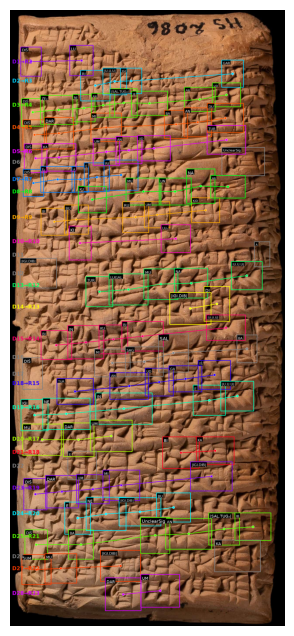

✓ Saved to: /home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree/alignment_results/debug_HS.2086_detection_rows.jpg


In [15]:
# ===== Step 6: Visualize matched rows - Detection with row numbers =====

import matplotlib.pyplot as plt

# Visualize detection rows with row numbers (D# prefix, 1-indexed)
det_row_vis = BboxVisualizer(color=(255, 0, 0))
det_row_vis.draw_rows(
    sub_tablet_detection.img.copy(),
    sub_tablet_detection.sign_boxes,
    show_labels=True,
    show_row_numbers=True,
    row_mapping=det_to_text,           # Show D#→R# mapping
    row_label_prefix="D",              # Detection rows use D prefix
    mapped_label_prefix="R",           # Mapped text rows use R prefix
    line_thickness=2,
    marker_size=5
)

print(f"Detection rows with row numbers (D# on left margin, D#→R# for matched)")
det_row_vis.display_result(vis_opt="draw")
det_row_vis.save(os.path.join(OUTPUT_DIR, f"debug_{sample}_detection_rows.jpg"))

In [16]:
# ===== Step 9: Within-row sign matching =====

from sign_alignment import match_signs_in_row_dp

# Perform sign-level matching for each matched row pair
row_sign_matches = {}  # {text_row_idx: [(text_sign_idx, det_sign_idx), ...]}

print(f"=== Within-Row Sign Matching ===")
print(f"Processing {len(matches)} matched row pairs...\n")

for text_row_idx, det_row_idx in matches:
    # Get sign sequences
    text_signs = text_row_sequences[text_row_idx]
    det_signs = det_row_sequences[det_row_idx]
    
    # Perform DP matching at sign level
    sign_matches, dp_matrix = match_signs_in_row_dp(
        detection_signs=det_signs,
        text_signs=text_signs,
        skip_text_penalty=0.5,
        skip_det_penalty=2.0,
        mismatch_cost=0.9
    )
    
    row_sign_matches[text_row_idx] = sign_matches
    
    print(f"Text row {text_row_idx} → Detection row {det_row_idx}:")
    print(f"  Text signs: {len(text_signs)}, Detection signs: {len(det_signs)}")
    print(f"  Matched signs: {len(sign_matches)}")
    print(f"  First 5 matches:")
    for i, (t_idx, d_idx) in enumerate(sign_matches[:5]):
        print(f"    {i+1}. Text[{t_idx}]={text_signs[t_idx]} ↔ Det[{d_idx}]={det_signs[d_idx]}")
    if len(sign_matches) > 5:
        print(f"    ... and {len(sign_matches)-5} more matches")
    print()

print(f"=== Sign Matching Summary ===")
total_text_signs = sum(len(text_row_sequences[t_idx]) for t_idx, _ in matches)
total_det_signs = sum(len(det_row_sequences[d_idx]) for _, d_idx in matches)
total_matched_signs = sum(len(sm) for sm in row_sign_matches.values())
print(f"Total text signs in matched rows: {total_text_signs}")
print(f"Total detection signs in matched rows: {total_det_signs}")
print(f"Total matched sign pairs: {total_matched_signs}")

=== Within-Row Sign Matching ===
Processing 21 matched row pairs...

Text row 1 → Detection row 0:
  Text signs: 5, Detection signs: 2
  Matched signs: 2
  First 5 matches:
    1. Text[0]=DIŠ ↔ Det[0]=DIŠ
    2. Text[2]=LU ↔ Det[1]=LU

Text row 2 → Detection row 1:
  Text signs: 13, Detection signs: 4
  Matched signs: 4
  First 5 matches:
    1. Text[3]=RI ↔ Det[0]=RI
    2. Text[4]=|U.U.U| ↔ Det[1]=|U.U.U|
    3. Text[5]=IGI ↔ Det[2]=IGI
    4. Text[6]=NE ↔ Det[3]=GAR

Text row 3 → Detection row 2:
  Text signs: 11, Detection signs: 8
  Matched signs: 8
  First 5 matches:
    1. Text[0]=DIŠ ↔ Det[0]=DIŠ
    2. Text[1]=ZE₂ ↔ Det[1]=ZE₂
    3. Text[2]=NI ↔ Det[2]=NI
    4. Text[3]=AN ↔ Det[3]=AN
    5. Text[4]=|SAL.TUG₂| ↔ Det[4]=|SAL.TUG₂|
    ... and 3 more matches

Text row 4 → Detection row 3:
  Text signs: 14, Detection signs: 6
  Matched signs: 6
  First 5 matches:
    1. Text[0]=DIŠ ↔ Det[0]=DIŠ
    2. Text[2]=DAR ↔ Det[1]=DAR
    3. Text[4]=MI ↔ Det[2]=MI
    4. Text[7]=BA ↔ Det

In [17]:
# ===== Step 10: Align text rows to detection rows based on sign matches =====

from sign_alignment import align_text_to_detection_rows

# Get all sign boxes grouped by row from both subtablets (as dictionaries)
det_rows = sub_tablet_detection.get_rows_dict()
text_rows = sub_tablet_text.get_rows_dict()

print(f"=== Row Alignment ===")
print(f"Aligning matched text rows to detection rows using baseline with slope...\n")

# Align all matched text rows to detection rows
aligned_text_boxes = align_text_to_detection_rows(
    det_rows=det_rows,
    text_rows=text_rows,
    text_to_det=text_to_det,
    row_sign_matches=row_sign_matches,
    avg_width=avg_width,
    avg_height=avg_height,
    min_width_ratio=2/3,
    max_width_ratio=4/3
)

print(f"\n=== Alignment Summary ===")
print(f"Total aligned sign boxes: {len(aligned_text_boxes)}")
print(f"Matched text rows aligned: {len(row_sign_matches)}")
print(f"(Only matched rows are processed; unmatched text rows are excluded)")


=== Row Alignment ===
Aligning matched text rows to detection rows using baseline with slope...


=== Alignment Summary ===
Total aligned sign boxes: 220
Matched text rows aligned: 21
(Only matched rows are processed; unmatched text rows are excluded)


In [18]:
# ===== Step 11: Create optimized (aligned) SubTablet =====

from sign_alignment import SubTablet

# Create new SubTablet with aligned sign boxes
sub_tablet_optim = SubTablet(
    sign_boxes=aligned_text_boxes,
    img=sub_tablet_detection.img,  # Use same image as detection
    name="optim",
    avg_width=avg_width,
    avg_height=avg_height
)

print(f"optimized subtablet created, info: {sub_tablet_optim.info}")

# Count signs per row in optim subtablet
from collections import Counter
optim_row_counts = Counter([sb.row_idx for sb in sub_tablet_optim.sign_boxes])
print(f"\n  Signs per row in optim subtablet:")
for row_idx in sorted(optim_row_counts.keys()):
    if row_idx >= 0:
        print(f"    Row {row_idx}: {optim_row_counts[row_idx]} signs")

print(f"\n  First 5 signs in optim subtablet:")
for i, sb in enumerate(sub_tablet_optim.sign_boxes[:5]):
    print(f"    {i+1}. {sb.sign_name} (row={sb.row_idx}): center=({sb.cx:.1f}, {sb.cy:.1f}), size=({sb.width:.1f}, {sb.height:.1f})")

optimized subtablet created, info: SubTablet 'optim':
  220 signs, 21 rows, 
  image shape: (2835, 1262, 3), heatmap shape: None
  avg_width: 138.99, avg_height: 133.66

  Signs per row in optim subtablet:
    Row 1: 5 signs
    Row 2: 13 signs
    Row 3: 11 signs
    Row 4: 14 signs
    Row 5: 8 signs
    Row 6: 9 signs
    Row 7: 8 signs
    Row 8: 15 signs
    Row 9: 11 signs
    Row 11: 9 signs
    Row 12: 10 signs
    Row 13: 7 signs
    Row 14: 25 signs
    Row 15: 7 signs
    Row 16: 9 signs
    Row 17: 11 signs
    Row 18: 12 signs
    Row 19: 10 signs
    Row 20: 9 signs
    Row 21: 9 signs
    Row 22: 8 signs

  First 5 signs in optim subtablet:
    1. DIŠ (row=1): center=(96.6, 237.6), size=(94.3, 133.5)
    2. KA (row=1): center=(212.3, 235.1), size=(139.0, 133.7)
    3. LU (row=1): center=(328.1, 232.6), size=(107.8, 140.3)
    4. UM (row=1): center=(467.0, 229.7), size=(139.0, 133.7)
    5. AN (row=1): center=(606.0, 226.7), size=(139.0, 133.7)


In [ ]:
# ===== Step 12: Build sign match info & visualize text mapping + alignment diagnostic =====

from sign_alignment.visualizer import BboxVisualizer, CompositeVisualizer, build_sign_match_info

# Build sign_match_info from matching results
text_sign_match_info, det_sign_match_info = build_sign_match_info(
    row_sign_matches=row_sign_matches,
    text_to_det=text_to_det,
    det_rows_dict=det_rows,
    optim_sign_boxes=sub_tablet_optim.sign_boxes
)

# Count categories
n_same = sum(1 for v in text_sign_match_info.values() if v["status"] == "same")
n_diff = sum(1 for v in text_sign_match_info.values() if v["status"] == "diff")
n_unmatched = sum(1 for v in text_sign_match_info.values() if v["status"] == "unmatched")
n_det_unmatched = sum(1 for v in det_sign_match_info.values() if v["status"] == "unmatched")

print(f"=== Sign Match Info ===")
print(f"  Matched, same label:    {n_same}")
print(f"  Matched, diff label:    {n_diff}")
print(f"  Unmatched text signs:   {n_unmatched}")
print(f"  Unmatched det signs:    {n_det_unmatched}")

# --- Text rows mapping (per-sign coloring) ---
text_row_vis = BboxVisualizer()
text_row_vis.draw_text_mapping(
    img=None,  # White canvas for text
    sign_boxes=sub_tablet_text.sign_boxes,
    row_mapping=text_to_det,
    sign_match_info=text_sign_match_info,
    mapped_label_prefix="D",
    line_thickness=2,
    marker_size=5
)
text_row_vis.display_result(vis_opt="draw")
text_row_vis.save(os.path.join(OUTPUT_DIR, f"debug_{sample}_text_rows_mapped.jpg"))

# --- Side-by-side: Detection rows + Text mapping ---
comp = CompositeVisualizer()
comp.compose(
    images=[det_row_vis.result, text_row_vis.result],
    layout=(1, 2),
    titles=[
        f"Detection Rows ({len(det_row_sequences)} rows)",
        f"Text Mapping ({len(text_row_sequences)} rows, {len(matches)} matched)"
    ],
    figsize=(20, 10)
)
# comp.display_result(vis_opt="draw")
comp.save(os.path.join(OUTPUT_DIR, f"debug_{sample}_rows_side_by_side.jpg"))

# --- Alignment Diagnostic ---
diag_vis = BboxVisualizer()
diag_vis.draw_alignment_diagnostic(
    img=sub_tablet_detection.img.copy(),
    detection_sign_boxes=sub_tablet_detection.sign_boxes,
    aligned_text_boxes=sub_tablet_optim.sign_boxes,
    det_sign_match_info=det_sign_match_info,
    text_sign_match_info=text_sign_match_info,
    det_to_text=det_to_text,
    line_thickness=2,
    marker_size=5
)
diag_vis.display_result(vis_opt="draw")
diag_vis.save(os.path.join(OUTPUT_DIR, f"debug_{sample}_alignment_diagnostic.jpg"))

In [20]:
# ===== Step 12b: Position offset analysis for matched signs =====

# Build match_pairs for offset analysis
match_pairs = {}
for text_row_idx, sign_matches in row_sign_matches.items():
    det_row_idx = text_to_det[text_row_idx]
    for t_idx, d_idx in sign_matches:
        match_pairs[(text_row_idx, t_idx)] = (det_row_idx, d_idx)

print(f"=== Position Offset Analysis (matched signs) ===")
print(f"For matched signs, aligned cx = det_box.cx, but cy = baseline_y(cx) ≠ det_box.cy")
print(f"Also: height = avg_height ({avg_height:.1f}), width = computed, not det_box dimensions\n")

offsets_cx = []
offsets_cy = []
offsets_w = []
offsets_h = []
for sb in sub_tablet_optim.sign_boxes:
    key = (sb.row_idx, sb.col_idx)
    if key in match_pairs:
        det_row_idx, det_sign_idx = match_pairs[key]
        det_box = det_rows[det_row_idx][det_sign_idx]
        offsets_cx.append(sb.cx - det_box.cx)
        offsets_cy.append(sb.cy - det_box.cy)
        offsets_w.append(sb.width - det_box.width)
        offsets_h.append(sb.height - det_box.height)

offsets_cx = np.array(offsets_cx)
offsets_cy = np.array(offsets_cy)
offsets_w = np.array(offsets_w)
offsets_h = np.array(offsets_h)

print(f"  Δcx: mean={offsets_cx.mean():.2f}, std={offsets_cx.std():.2f}, |max|={np.abs(offsets_cx).max():.2f}")
print(f"  Δcy: mean={offsets_cy.mean():.2f}, std={offsets_cy.std():.2f}, |max|={np.abs(offsets_cy).max():.2f}")
print(f"  Δw:  mean={offsets_w.mean():.2f}, std={offsets_w.std():.2f}, |max|={np.abs(offsets_w).max():.2f}")
print(f"  Δh:  mean={offsets_h.mean():.2f}, std={offsets_h.std():.2f}, |max|={np.abs(offsets_h).max():.2f}")
print(f"\n  → Δcx should be ~0 (uses det_box.cx directly)")
print(f"  → Δcy ≠ 0 because baseline_y(cx) ≠ det_box.cy (forced onto regression line)")
print(f"  → Δw ≠ 0 because width is recomputed from spacing, not det_box.width")
print(f"  → Δh ≠ 0 because height is always avg_height, not det_box.height")

=== Position Offset Analysis (matched signs) ===
For matched signs, aligned cx = det_box.cx, but cy = baseline_y(cx) ≠ det_box.cy
Also: height = avg_height (133.7), width = computed, not det_box dimensions

  Δcx: mean=-10.00, std=55.67, |max|=326.25
  Δcy: mean=0.67, std=5.05, |max|=28.89
  Δw:  mean=0.18, std=7.12, |max|=52.53
  Δh:  mean=0.17, std=4.24, |max|=31.26

  → Δcx should be ~0 (uses det_box.cx directly)
  → Δcy ≠ 0 because baseline_y(cx) ≠ det_box.cy (forced onto regression line)
  → Δw ≠ 0 because width is recomputed from spacing, not det_box.width
  → Δh ≠ 0 because height is always avg_height, not det_box.height


In [21]:
rows  = sub_tablet_optim.get_row_sign_sequences()
for i, row in enumerate(rows):
    print(row)

['DIŠ', 'KA', 'LU', 'UM', 'AN']
['GABA', 'I', 'TUM', 'RI', '|U.U.U|', 'IGI', 'NE', 'NE', 'IN', 'GAR', 'RI', '|U.U.U|', 'MA']
['DIŠ', 'ZE₂', 'NI', 'AN', '|SAL.TUG₂|', 'IB', 'TUR', 'AN', 'UD', 'GA', 'IŠ']
['DIŠ', 'AŠ@z', 'DAR', 'UM', 'MI', '|SAL.KUR|', 'ME', 'BA', 'AN', 'DU', 'NE', 'IN', 'NE', '|U.U.U|']
['DIŠ', 'KA', 'LU', 'UM', 'AN', 'UD', 'TUR', 'LUGAL']
['DIŠ', 'E₂', 'A', 'E', 'RI', 'BA', '|GUD×KUR|', 'DUN₃@g@g', 'UŠ']
['|PA.DU@s|', 'EŠ₂', 'MU', 'UN', 'NA', 'AN', 'TUK', 'UŠ']
['DI', 'BI', 'BU', '|UD.KUŠU₂|', 'RU', 'UM', '|EN.KID|', 'KI', 'KA', 'KU', 'BI', 'DA', 'NE', 'IN', 'KA']
['|EN.KID|', 'KI', 'TA', 'AN', 'EN', 'KID', 'LU₂', 'ŠA₆', 'GU₂', 'EN', 'NA']
['DUN₃@g@g', 'UŠ', 'TUR', 'LUGAL', 'MU', 'NA', 'TE', '|U.U.U|', 'MA']
['GU₂', 'EN', 'NA', '|IGI.DIB|', '|PA.TE.SI|', '|IGI.DIB|', 'DI', 'TAR', 'E', 'NE']
['DI', 'BI', 'IN', 'KU', 'BI', '|U.U.U|', '|A.AN|']
['DIŠ', 'AŠ@z', 'DAR', 'UM', 'MI', 'SAG', 'SAL', '|SAL.KUR|', 'RU', 'BA', 'TUM', '|SAL.ME|', 'AN', '|SAL.TUG₂|', 'IB', 'TUR', 'SA

In [22]:
# ===== Step 13: PSR (Point Set Registration) Optimization =====

from sign_alignment import PointSetRegistrationOptimizer

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Create PSR optimizer using the coarse-aligned subtablet as initialization
optimizer = PointSetRegistrationOptimizer(
    sub_tablet_text=sub_tablet_optim,  # Use coarse-aligned result as starting point
    target_detections=exp_image.detections,
    sigma=avg_width * 1.5,        # GMM bandwidth (wider → broader attraction)
    w_noise=0.1,                  # 10% uniform background noise
    lambda_data=1.0,
    lambda_anchor=0.01,
    lambda_seq=0.1,
    lambda_height=0.01,
    lambda_rows=0.1,
    rows_threshold_ratio=1.0/3.0,
    device=device,
)

print(f"=== PSR Optimizer Created ===")
print(f"  Device: {optimizer.device}")
print(f"  Source points (M): {optimizer.M}")
print(f"  Target points (N): {optimizer.N}")
print(f"  Sigma: {optimizer.sigma:.1f}")
print(f"  w_noise: {optimizer.w_noise}")
print(f"  Lambdas: data={optimizer.lambda_data}, anchor={optimizer.lambda_anchor}, "
      f"seq={optimizer.lambda_seq}, height={optimizer.lambda_height}, rows={optimizer.lambda_rows}")


=== PSR Optimizer Created ===
  Device: cuda
  Source points (M): 220
  Target points (N): 100
  Sigma: 208.5
  w_noise: 0.1
  Lambdas: data=1.0, anchor=0.01, seq=0.1, height=0.01, rows=0.1


In [23]:
# ===== Step 14: Run PSR optimization =====

sub_tablet_final = optimizer.optimize(
    num_iterations=100,
    lr=1.0,
    sigma_anneal=True,        # anneal sigma for coarse→fine matching
    sigma_final=None,         # defaults to sigma/4
    verbose=True,
    log_every=20,
)

print(f"\n=== Optimization Complete ===")
print(f"Final subtablet: {len(sub_tablet_final)} signs")

Point Set Registration Optimizer
  Source (text):  220 signs, 21 rows
  Target (det):   100 signs
  Device:         cuda
  sigma:          208.5 → 52.1
  w_noise:        0.1
  Lambdas:  data=1.0, anchor=0.01, seq=0.1, height=0.01, rows=0.1
------------------------------------------------------------
Iter    0: total=78.7676  data=6.9077  anchor=5.7593  seq=712.3572  height=51.4030  rows=0.5248  σ=208.5
Iter   20: total=27.0567  data=6.9077  anchor=0.2139  seq=200.8605  height=2.6336  rows=0.3446  σ=176.9
Iter   40: total=13.1159  data=6.9077  anchor=0.0284  seq=61.7691  height=0.2752  rows=0.2819  σ=145.3
Iter   60: total=8.6136  data=6.9077  anchor=0.0034  seq=16.8020  height=0.0539  rows=0.2513  σ=113.7
Iter   80: total=7.2679  data=6.9077  anchor=0.0009  seq=3.3698  height=0.0071  rows=0.2316  σ=82.1
Iter   99: total=6.9805  data=6.9076  anchor=0.0003  seq=0.5096  height=0.0016  rows=0.2197  σ=52.1

=== Optimization Complete ===
Final subtablet: 220 signs


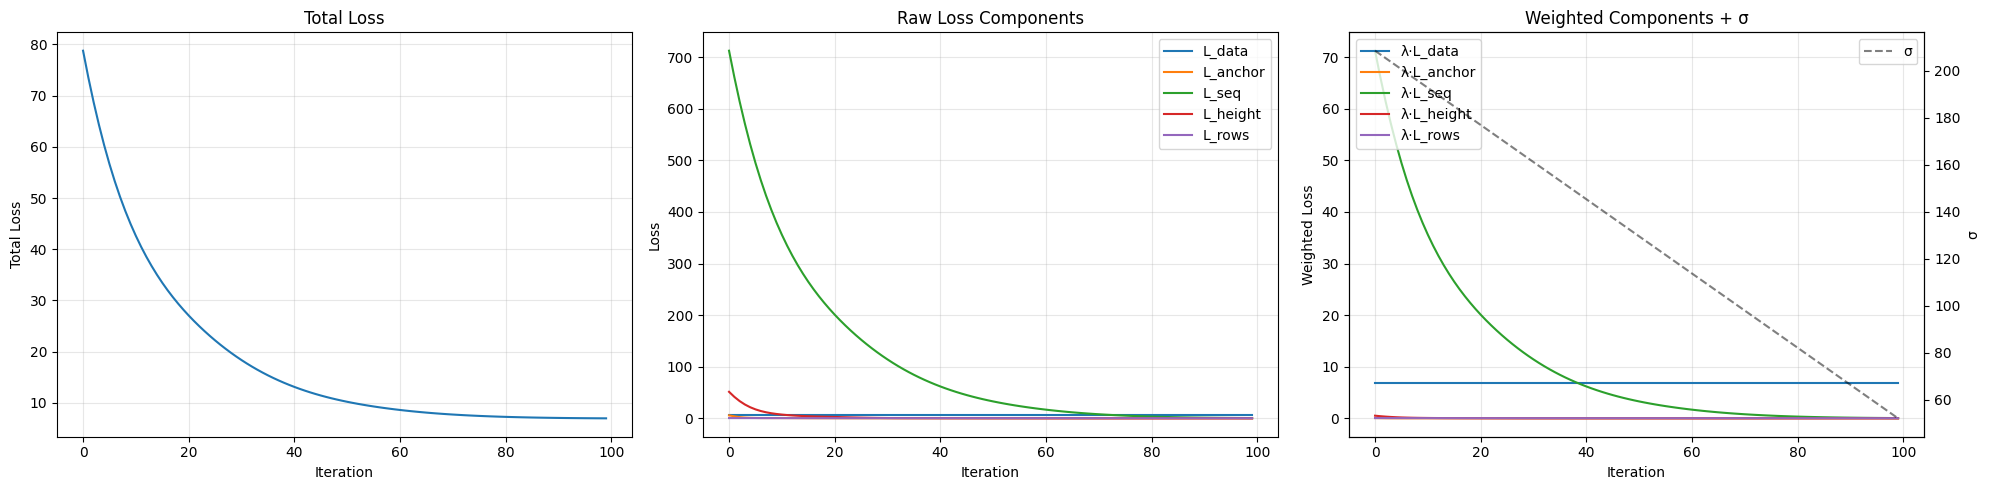

In [24]:
# ===== Step 15: Optimization loss history =====

optimizer.plot_loss_history()

✓ Saved to: /home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree/alignment_results/debug_HS.2086_final_optimized_subtablet.jpg


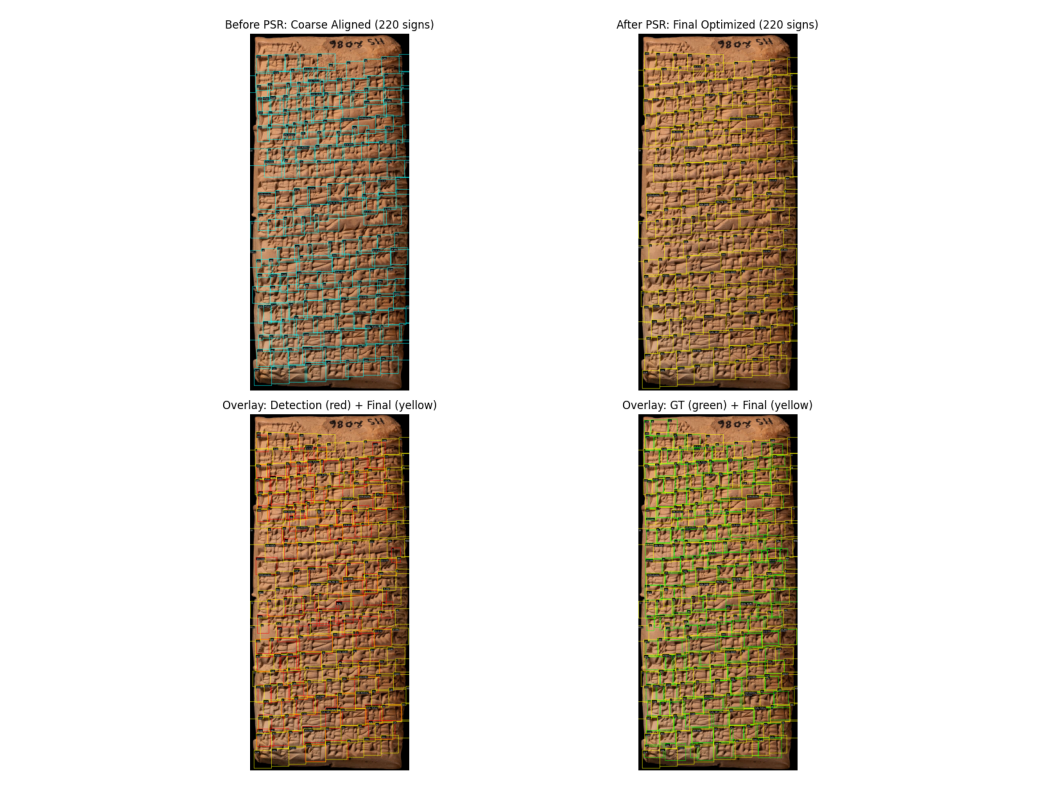

✓ Saved to: /home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree/alignment_results/debug_HS.2086_results_comparison.jpg
Cyan = Coarse aligned,  Yellow = Final optimized,  Red = Detection,  Green = Ground Truth


In [25]:
# ===== Step 16: Results comparison =====

from sign_alignment.visualizer import BboxVisualizer, CompositeVisualizer

# (0,0) Before PSR: coarse-aligned (cyan)
before_vis = BboxVisualizer(color=(0, 255, 255))
before_vis.draw_boxes(exp_image.img.copy(), sub_tablet_optim.to_detection_list())

# (0,1) After PSR: final optimized (yellow)
after_vis = BboxVisualizer(color=(255, 255, 0))
after_vis.draw_boxes(exp_image.img.copy(), sub_tablet_final.to_detection_list())
after_vis.save(os.path.join(OUTPUT_DIR, f"debug_{sample}_final_optimized_subtablet.jpg"))

# (1,0) Detection (red) + Final (yellow)
det_ov = BboxVisualizer(color=(255, 0, 0))
det_ov.draw_boxes(exp_image.img.copy(), sub_tablet_detection.to_detection_list())
opt_ov = BboxVisualizer(color=(255, 255, 0))
opt_ov.draw_boxes(det_ov.result, sub_tablet_final.to_detection_list())

# (1,1) Ground Truth (green) + Final (yellow)
gt_ov = BboxVisualizer(color=(0, 255, 0))
gt_ov.draw_boxes(exp_image.img.copy(), gt_boxes_exp)
opt_gt = BboxVisualizer(color=(255, 255, 0))
opt_gt.draw_boxes(gt_ov.result, sub_tablet_final.to_detection_list())

# Compose 2×2 grid
comp = CompositeVisualizer()
comp.compose(
    images=[before_vis.result, after_vis.result, opt_ov.result, opt_gt.result],
    layout=(2, 2),
    titles=[
        f"Before PSR: Coarse Aligned ({len(sub_tablet_optim)} signs)",
        f"After PSR: Final Optimized ({len(sub_tablet_final)} signs)",
        "Overlay: Detection (red) + Final (yellow)",
        "Overlay: GT (green) + Final (yellow)"
    ],
    figsize=(16, 12)
)
comp.display_result(vis_opt="draw")
comp.save(os.path.join(OUTPUT_DIR, f"debug_{sample}_results_comparison.jpg"))

print("Cyan = Coarse aligned,  Yellow = Final optimized,  Red = Detection,  Green = Ground Truth")

In [26]:
# ===== Step 17: Analyze parameter changes =====

param_changes = optimizer.get_param_changes()

print("=== Parameter Changes (Coarse → Final) ===")
print(f"  Δcx: mean={param_changes[:, 0].mean():.2f}, std={param_changes[:, 0].std():.2f}, "
      f"|max|={np.abs(param_changes[:, 0]).max():.2f}")
print(f"  Δcy: mean={param_changes[:, 1].mean():.2f}, std={param_changes[:, 1].std():.2f}, "
      f"|max|={np.abs(param_changes[:, 1]).max():.2f}")
print(f"  Δw:  mean={param_changes[:, 2].mean():.2f}, std={param_changes[:, 2].std():.2f}")
print(f"  Δh:  mean={param_changes[:, 3].mean():.2f}, std={param_changes[:, 3].std():.2f}")

# Per-sign details (first 5)
print("\n=== First 5 Signs: Coarse → Final ===")
for i in range(min(5, len(sub_tablet_optim.sign_boxes))):
    before = sub_tablet_optim.sign_boxes[i]
    after = sub_tablet_final.sign_boxes[i]
    print(f"  {i+1}. {before.sign_name}:")
    print(f"      Coarse: cx={before.cx:.1f}, cy={before.cy:.1f}, "
          f"w={before.width:.1f}, h={before.height:.1f}")
    print(f"      Final:  cx={after.cx:.1f}, cy={after.cy:.1f}, "
          f"w={after.width:.1f}, h={after.height:.1f}")
    print(f"      Δ:      Δcx={after.cx-before.cx:.1f}, Δcy={after.cy-before.cy:.1f}, "
          f"Δw={after.width-before.width:.1f}, Δh={after.height-before.height:.1f}")

=== Parameter Changes (Coarse → Final) ===
  Δcx: mean=1.02, std=13.48, |max|=61.87
  Δcy: mean=-4.12, std=18.32, |max|=52.51
  Δw:  mean=-5.81, std=14.22
  Δh:  mean=-2.35, std=8.24

=== First 5 Signs: Coarse → Final ===
  1. DIŠ:
      Coarse: cx=96.6, cy=237.6, w=94.3, h=133.5
      Final:  cx=94.4, cy=213.8, w=92.7, h=135.8
      Δ:      Δcx=-2.2, Δcy=-23.7, Δw=-1.6, Δh=2.3
  2. KA:
      Coarse: cx=212.3, cy=235.1, w=139.0, h=133.7
      Final:  cx=208.3, cy=218.4, w=135.1, h=135.8
      Δ:      Δcx=-4.1, Δcy=-16.7, Δw=-3.9, Δh=2.2
  3. LU:
      Coarse: cx=328.1, cy=232.6, w=107.8, h=140.3
      Final:  cx=332.9, cy=223.5, w=114.0, h=135.8
      Δ:      Δcx=4.8, Δcy=-9.2, Δw=6.2, Δh=-4.5
  4. UM:
      Coarse: cx=467.0, cy=229.7, w=139.0, h=133.7
      Final:  cx=461.9, cy=228.7, w=144.2, h=135.8
      Δ:      Δcx=-5.1, Δcy=-1.0, Δw=5.3, Δh=2.2
  5. AN:
      Coarse: cx=606.0, cy=226.7, w=139.0, h=133.7
      Final:  cx=604.3, cy=234.4, w=140.4, h=135.8
      Δ:      Δcx=-1.8, Δc